In [ ]:
pip install -q gensim scikit-learn tensorflow transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 67.2 MB/s eta 0:00:00


In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from gensim.models import Word2Vec, FastText
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D
from tensorflow.keras.models import Sequential

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow version: 2.21.0
Libraries imported successfully.


In [ ]:
texts = [
    "artificial intelligence enables machines to learn",
    "machine learning helps computers recognize patterns",
    "deep learning uses neural networks",
    "neural networks support image recognition",
    "computer vision analyzes images and videos",
    "robotics combines sensors motors and control",
    "robots use sensors to navigate environments",
    "embedded systems control electronic devices",
    "microcontrollers manage motors and sensors",
    "natural language processing understands human language",
    "language models generate and understand text",
    "transformers learn contextual word representations",
    "bert generates contextual representations of words",
    "word embeddings represent words as vectors",
    "fasttext uses subword information for word vectors",
    "word2vec learns relationships between words",
    "data science uses statistics and machine learning",
    "artificial intelligence supports automation",
    "robots perform automated tasks",
    "computers process data using algorithms",
    "students study artificial intelligence and robotics",
    "neural networks learn from training data",
    "image processing improves visual understanding",
    "language understanding depends on context",
]

def tokenize(text):
    return re.findall(r"\b[a-z]+\b", text.lower())

tokenized_sentences = [tokenize(text) for text in texts]

print("Number of documents:", len(texts))
print("First document:", texts[0])
print("Tokenized document:", tokenized_sentences[0])

Number of documents: 24
First document: artificial intelligence enables machines to learn
Tokenized document: ['artificial', 'intelligence', 'enables', 'machines', 'to', 'learn']


In [ ]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)

terms = tfidf.get_feature_names_out()

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("First 15 vocabulary terms:", terms[:15])

TF-IDF matrix shape: (24, 90)
First 15 vocabulary terms: ['algorithms' 'analyzes' 'and' 'artificial' 'as' 'automated' 'automation'
 'bert' 'between' 'combines' 'computer' 'computers' 'context' 'contextual'
 'control']


In [ ]:
def tfidf_similar_words(query, top_n=5):
    if query not in tfidf.vocabulary_:
        print(f"'{query}' is not in the vocabulary.")
        return

    word_index = tfidf.vocabulary_[query]
    word_vectors = tfidf_matrix.T.toarray()
    similarities = cosine_similarity(
        word_vectors[word_index].reshape(1, -1),
        word_vectors
    )[0]

    order = np.argsort(similarities)[::-1]
    results = [
        (terms[i], similarities[i])
        for i in order
        if terms[i] != query
    ][:top_n]

    print(f"Top similar words for '{query}' using TF-IDF:")
    for word, score in results:
        print(f"{word}: {score:.4f}")

tfidf_similar_words("robotics")

Top similar words for 'robotics' using TF-IDF:
combines: 0.7102
students: 0.7040
study: 0.7040
and: 0.5911
control: 0.5123


In [ ]:
w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=2,
    sg=1,          # 1 = Skip-gram; 0 = CBOW
    epochs=200,
    seed=42
)

print("Vocabulary size:", len(w2v_model.wv))
print("Vector dimension:", w2v_model.wv.vector_size)
print("Vector for 'robotics':")
print(w2v_model.wv["robotics"][:10])

Vocabulary size: 89
Vector dimension: 50
Vector for 'robotics':
[ 0.00898543 -0.01340278  0.00122708  0.0048831  -0.0114009   0.06131957
 -0.02816128  0.06033546 -0.06958839 -0.01390901]


In [ ]:
def word2vec_similar_words(query, top_n=5):
    if query not in w2v_model.wv:
        print(f"'{query}' is not in the vocabulary.")
        return

    for word, score in w2v_model.wv.most_similar(
        query, topn=top_n
    ):
        print(f"{word}: {score:.4f}")

print("Word2Vec similarity results:")
word2vec_similar_words("robotics")

Word2Vec similarity results:
sensors: 0.9486
vectors: 0.9485
language: 0.9485
understanding: 0.9477
and: 0.9463


In [ ]:
fasttext_model = FastText(
    sentences=tokenized_sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=2,
    sg=1,
    min_n=3,
    max_n=6,
    epochs=200,
    seed=42
)

print("FastText vector dimension:",
      fasttext_model.wv.vector_size)

print("Similar words to 'robotics':")
for word, score in fasttext_model.wv.most_similar(
    "robotics", topn=5
):
    print(f"{word}: {score:.4f}")

FastText vector dimension: 50
Similar words to 'robotics':
robots: 0.9991
machines: 0.9990
computers: 0.9989
machine: 0.9989
computer: 0.9988


In [ ]:
rare_word = "roboticsengineering"

print("In Word2Vec vocabulary:",
      rare_word in w2v_model.wv.key_to_index)

print("In FastText vocabulary:",
      rare_word in fasttext_model.wv.key_to_index)

print("FastText vector for an unseen word:")
print(fasttext_model.wv[rare_word][:10])

In Word2Vec vocabulary: False
In FastText vocabulary: False
FastText vector for an unseen word:
[ 0.00660441  0.06484536  0.01234967 -0.01859228  0.03486048  0.08938043
 -0.01858411 -0.01251418  0.01379027  0.07006061]


In [ ]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
vocab_size = len(tokenizer.word_index) + 1

max_length = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

embedding_dim = 32

keras_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    ),
    GlobalAveragePooling1D()
])

keras_model.compile(
    optimizer="adam",
    loss="mse"
)

print("Vocabulary size:", vocab_size)
print("Padded input shape:", padded_sequences.shape)
print("Model summary:")
keras_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vocabulary size: 92
Padded input shape: (24, 7)
Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
keras_model.fit(
    padded_sequences,
    np.zeros((len(texts), 1), dtype=np.float32),
    epochs=5,
    batch_size=4,
    verbose=1
)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4214e-04
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.1064e-05 
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.9910e-05 
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.2698e-05 
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1059e-05


In [ ]:
keras_embedding_weights = keras_model.layers[0].get_weights()[0]

print("Keras embedding matrix shape:",
      keras_embedding_weights.shape)

for word in ["robotics", "machine", "language"]:
    word_id = tokenizer.word_index.get(word)

    if word_id is not None:
        print(word, keras_embedding_weights[word_id][:8])

Keras embedding matrix shape: (92, 32)
robotics [ 0.02066693  0.00456472 -0.02485013  0.01075708  0.0276934  -0.03450344
  0.03442519 -0.02629207]
machine [-0.04196006 -0.00127104 -0.0117251  -0.02423059 -0.00625008 -0.0144419
  0.04263042  0.03050351]
language [ 0.00480482 -0.04219563 -0.02060521  0.02021607  0.00291115 -0.02943948
 -0.02618725 -0.02122999]


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

model_name = "google-bert/bert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)
bert_model.eval()

print("BERT loaded successfully.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded successfully.


In [ ]:
def get_bert_word_embedding(sentence, target_word):
    inputs = bert_tokenizer(
        sentence,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = bert_model(**inputs)

    tokens = bert_tokenizer.convert_ids_to_tokens(
        inputs["input_ids"][0]
    )

    target_pieces = bert_tokenizer.tokenize(target_word)
    target_positions = []

    for i in range(len(tokens) - len(target_pieces) + 1):
        if tokens[i:i + len(target_pieces)] == target_pieces:
            target_positions = list(
                range(i, i + len(target_pieces))
            )
            break

    if not target_positions:
        raise ValueError("Target word was not found.")

    # Average the subword representations of the target word.
    embedding = outputs.last_hidden_state[
        0, target_positions, :
    ].mean(dim=0)

    return embedding.cpu().numpy()

sentence1 = "She deposited money at the bank."
sentence2 = "They sat on the bank of the river."

bank1 = get_bert_word_embedding(sentence1, "bank")
bank2 = get_bert_word_embedding(sentence2, "bank")

context_similarity = cosine_similarity(
    bank1.reshape(1, -1),
    bank2.reshape(1, -1)
)[0, 0]

print("BERT vector dimension:", bank1.shape)
print("Context 1:", sentence1)
print("Context 2:", sentence2)
print("Cosine similarity:", round(float(context_similarity), 4))

BERT vector dimension: (768,)
Context 1: She deposited money at the bank.
Context 2: They sat on the bank of the river.
Cosine similarity: 0.54


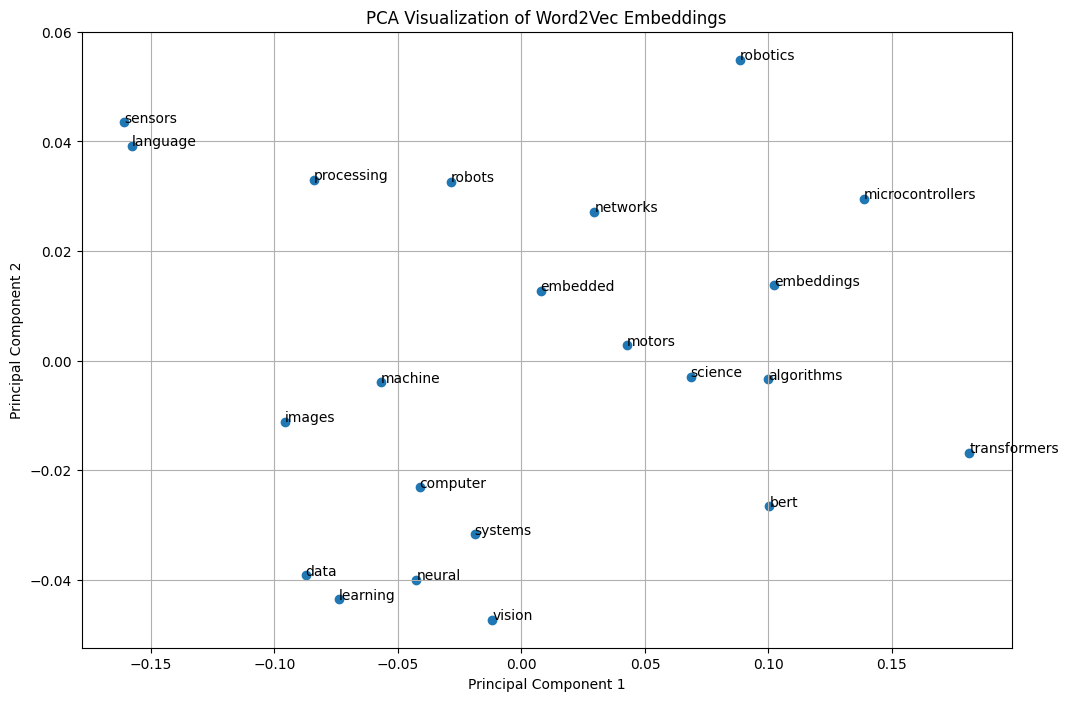

Explained variance ratio: [0.532778   0.05872414]
Total variance shown: 0.5915


In [ ]:
words_to_plot = [
    "robotics", "robots", "sensors", "motors",
    "embedded", "systems", "microcontrollers",
    "machine", "learning", "neural", "networks",
    "language", "processing", "transformers",
    "bert", "embeddings", "computer", "vision",
    "images", "data", "science", "algorithms"
]

words_to_plot = [
    word for word in words_to_plot
    if word in w2v_model.wv
]

vectors = np.array([
    w2v_model.wv[word] for word in words_to_plot
])

pca = PCA(n_components=2)
coordinates = pca.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coordinates[:, 0], coordinates[:, 1])

for i, word in enumerate(words_to_plot):
    plt.annotate(
        word,
        (coordinates[i, 0], coordinates[i, 1])
    )

plt.title("PCA Visualization of Word2Vec Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance shown:",
      round(float(pca.explained_variance_ratio_.sum()), 4))

In [ ]:
query_words = ["robotics", "language", "learning"]

for query in query_words:
    print("\n" + "=" * 45)
    print("QUERY WORD:", query)

    if query in w2v_model.wv:
        print("\nWord2Vec:")
        print(w2v_model.wv.most_similar(query, topn=5))

    if query in fasttext_model.wv:
        print("\nFastText:")
        print(fasttext_model.wv.most_similar(query, topn=5))

    tfidf_similar_words(query, top_n=5)


QUERY WORD: robotics

Word2Vec:
[('sensors', 0.9485916495323181), ('vectors', 0.9485156536102295), ('language', 0.9485064148902893), ('understanding', 0.9477446675300598), ('and', 0.9463359117507935)]

FastText:
[('robots', 0.9990531206130981), ('machines', 0.9989762306213379), ('computers', 0.9989140033721924), ('machine', 0.9988572001457214), ('computer', 0.9988343715667725)]
Top similar words for 'robotics' using TF-IDF:
combines: 0.7102
students: 0.7040
study: 0.7040
and: 0.5911
control: 0.5123

QUERY WORD: language

Word2Vec:
[('artificial', 0.9795969724655151), ('sensors', 0.975789487361908), ('vectors', 0.9748586416244507), ('words', 0.9745303392410278), ('to', 0.974529504776001)]

FastText:
[('understands', 0.9994165301322937), ('understand', 0.9994099736213684), ('understanding', 0.9993558526039124), ('context', 0.9991477727890015), ('representations', 0.9991331100463867)]
Top similar words for 'language' using TF-IDF:
understands: 0.7730
natural: 0.7730
human: 0.7730
process

In [ ]:
from tensorflow.keras.layers import Dense

# Create training examples: previous words -> next word
input_sequences = []

for seq in sequences:
    for i in range(1, len(seq)):
        input_sequences.append(seq[:i + 1])

max_length = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_length,
    padding="pre"
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

keras_lm = Sequential([
    Embedding(vocab_size, 32),
    GlobalAveragePooling1D(),
    Dense(vocab_size, activation="softmax")
])

keras_lm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = keras_lm.fit(
    X, y,
    epochs=100,
    batch_size=8,
    verbose=0
)

print("Final training accuracy:",
      round(float(history.history["accuracy"][-1]), 4))

keras_embedding_weights = keras_lm.layers[0].get_weights()[0]
print("Learned embedding matrix:",
      keras_embedding_weights.shape)

Final training accuracy: 0.3945
Learned embedding matrix: (92, 32)


In [ ]:
def cosine_between(a, b):
    return float(cosine_similarity(
        a.reshape(1, -1),
        b.reshape(1, -1)
    )[0, 0])

# Static Word2Vec gives the same vector for "bank"
if "bank" in w2v_model.wv:
    static_bank = w2v_model.wv["bank"]
    print("Word2Vec static bank vector:",
          static_bank.shape)

# BERT gives context-dependent vectors
print("BERT similarity across the two contexts:",
      round(cosine_between(bank1, bank2), 4))

BERT similarity across the two contexts: 0.54
